# Record and change a small digit model

Train a two-pathway digit classifier, silence one pathway, and compare its saved predictions and activity. Then restore the model and replay the inputs.

**Requirements:** CPU; bundled scikit-learn digit images, no download. Use the [UMI notebook environment](../install/README.md) and run cells in order. This demonstrates tools on held-out images, not brain similarity.


In [1]:
from contextlib import contextmanager
from pathlib import Path
import hashlib
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# Brain-Score needs a subject: the model it will send inputs to.
from brainscore_core.model_interface import Subject
# Sessions hold the exchange; events carry each input or response.
from brainscore_core.streaming import InMemorySession, StreamEvent
# These tools organize the run, save measurements, and change selected model parts.
from brainscore.experiments import (
    Experiment, SessionProtocol, RecordInputsOutputs, RecordActivity,
    Ablate, TorchInstrumentation, replay_sessions, compare_outputs,
)

SEED = 7
output_root = Path(tempfile.mkdtemp(prefix='umi-digit-toolbox-'))
COLORS = {'normal': '#0072B2', 'silenced': '#D55E00', 'restored': '#009E73'}
LABELS = {'normal': 'Normal model', 'silenced': 'Upper pathway silenced',
          'restored': 'After cleanup'}
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
print('Outputs:', output_root)
print('Device: CPU')


Outputs: /var/folders/h6/g53mxg516n538136hh74630r0000gn/T/umi-digit-toolbox-cqmpm2wb
Device: CPU


## 1. Prepare and train the model

Each 8×8 image is split into its upper and lower four rows. Separate pathways learn 32 features each; a final layer combines them to predict a digit. These names describe the image halves, not Brain-Score categories.

Reserve 20% of images for testing. Labels stay outside the subject and are used only to score its predictions. Silencing a pathway zeros its output, leaving the image and weights unchanged.


1437 training images; 360 held-out images.


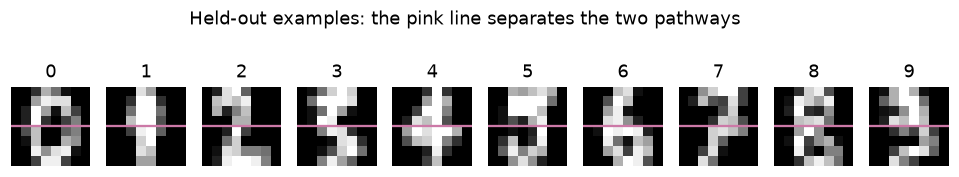

In [2]:
digits = load_digits()
images = (digits.images / 16.0).astype(np.float32)
labels = digits.target
train_ids, test_ids = train_test_split(
    np.arange(len(images)), test_size=0.2, random_state=SEED, stratify=labels,
)
assert not set(train_ids) & set(test_ids)
X_train = torch.from_numpy(images[train_ids])
y_train = torch.tensor(labels[train_ids], dtype=torch.long)
X_test = images[test_ids].copy()
y_test = labels[test_ids].copy()
print(f'{len(train_ids)} training images; {len(test_ids)} held-out images.')

fig, axes = plt.subplots(1, 10, figsize=(11, 1.8))
for digit, ax in enumerate(axes):
    image = X_test[np.flatnonzero(y_test == digit)[0]]
    ax.imshow(image, cmap='gray', vmin=0, vmax=1)
    ax.axhline(3.5, color='#CC79A7', linewidth=1.5)
    ax.set_title(str(digit))
    ax.axis('off')
fig.suptitle('Held-out examples: the pink line separates the two pathways', y=1.08)
plt.show()


In [3]:
class TwoPathDigitModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.upper = torch.nn.Sequential(torch.nn.Linear(32, 32), torch.nn.ReLU())
        self.lower = torch.nn.Sequential(torch.nn.Linear(32, 32), torch.nn.ReLU())
        self.readout = torch.nn.Linear(64, 10)

    def forward(self, pixels):
        upper = self.upper(pixels[:, :4, :].reshape(-1, 32))
        lower = self.lower(pixels[:, 4:, :].reshape(-1, 32))
        return self.readout(torch.cat([upper, lower], dim=1))

# Limit CPU threads during training; restore the kernel's setting afterward.
previous_threads = torch.get_num_threads()
try:
    torch.set_num_threads(2)
    with torch.random.fork_rng(devices=[]):
        torch.manual_seed(SEED)
        model = TwoPathDigitModel().cpu()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    losses = []
    model.train()
    for epoch in range(250):
        optimizer.zero_grad()
        loss = torch.nn.functional.cross_entropy(model(X_train), y_train)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach()))
finally:
    torch.set_num_threads(previous_threads)
model.eval()

weights = {name: value.detach().cpu().numpy() for name, value in model.state_dict().items()}
np.savez(output_root / 'trained-weights.npz', **weights)
checkpoint_hash = hashlib.sha256((output_root / 'trained-weights.npz').read_bytes()).hexdigest()
np.savez(output_root / 'split.npz', train_ids=train_ids, test_ids=test_ids)
print(f'{sum(p.numel() for p in model.parameters()):,} parameters; final training loss {losses[-1]:.4f}')
print('Saved weights and the train/test split beside the experiment records.')


2,762 parameters; final training loss 0.0073
Saved weights and the train/test split beside the experiment records.


## 2. Connect the model to a session

`Subject` adapts the model for Brain-Score. `InMemorySession` holds the test images and collects predictions. The model has no memory between inputs.

`@contextmanager` supplies a session with Python-managed setup and cleanup. `SessionProtocol` repeats that setup for each condition; each condition has one trial by default.


In [4]:
# Connect an ordinary PyTorch model to Brain-Score.
class DigitSubject(Subject):
    # A name for this model in the saved records.
    identifier = 'two-path-digits'
    # The kind of input this subject accepts.
    in_channels = {'image'}
    # The kind of response this subject returns.
    out_channels = {'choice'}

    def __init__(self, network):
        self.network = network

    def reset(self):
        pass  # No memory, queued actions, or random sampling during inference.

    # Receive inputs and return predictions until the session ends.
    def interact(self, session):
        while (event := session.next_input()) is not None:
            with torch.inference_mode():
                probabilities = self.network(
                    torch.from_numpy(event.payload['pixels'])
                ).softmax(dim=1).numpy()
            # Send predictions back with IDs so they can be matched to images.
            session.emit(StreamEvent('choice', {
                'probabilities': probabilities,
                'predicted_digit': probabilities.argmax(axis=1),
                'sample_ids': event.payload['sample_ids'].copy(),
            }, t_ms=event.t_ms))

# The experiment talks to this adapter; the underlying model stays unchanged.
subject = DigitSubject(model)

@contextmanager
def make_session(trial):
    # Hold the inputs in memory; time zero labels this presentation.
    yield InMemorySession([StreamEvent('image', {
        'pixels': X_test.copy(), 'sample_ids': test_ids.copy(),
    }, t_ms=0)])  # Start this presentation at experiment time zero.

# Schedule the conditions and reset the subject between them.
protocol = SessionProtocol(
    'matched-held-out-digits', make_session,
    # Run these conditions in order, using the same inputs.
    conditions=['normal', 'silenced', 'restored'],
    # Check that the session and subject agree on inputs and outputs.
    input_channels=['image'], output_channels=['choice'],
    metadata={'split_seed': SEED, 'held_out_images': len(test_ids)},
)


## 3. Choose the tools and run

Compare normal, silenced, and restored conditions on identical inputs. `Ablate` zeros `upper` only in the silenced condition. `RecordActivity` saves both pathways after the change. Tools detach at each trial's end.


In [5]:
# Assemble the model, schedule, tools, and output location.
experiment = Experiment(
    subject=subject,  # The model adapter to run.
    protocol=protocol,  # The conditions and inputs to present.
    tools=[
        RecordInputsOutputs(),  # Save what the model receives and returns.
        Ablate(['upper'], conditions=['silenced']),  # Zero this pathway only in this condition.
        RecordActivity(['upper', 'lower'], when='after'),  # Save both pathways after the change.
    ],
    instrumentation=TorchInstrumentation(model),  # Expose the model's actual layer paths to the tools.
    output_dir=output_root / 'experiment',  # Save this run in a new folder.
    metadata={
        'training_seed': SEED,
        'checkpoint_sha256': checkpoint_hash,
        'training_epochs': 250,
        'device': 'cpu',
        'dataset': 'sklearn.load_digits; bundled handwritten digits',
    },
)
plan = experiment.validate()
print('Tools:', [tool['name'] for tool in plan['tools']])
result = experiment.run()  # Attach tools, run all conditions, save results, then remove tools.
print('Run status:', result.manifest['status'])


Tools: ['inputs_outputs', 'ablation', 'activity']
Run status: complete


## 4. Read the recorded predictions

Accuracy is the percentage of test images classified correctly. Both plots use saved responses: the first summarizes all images, and the second includes every digit.


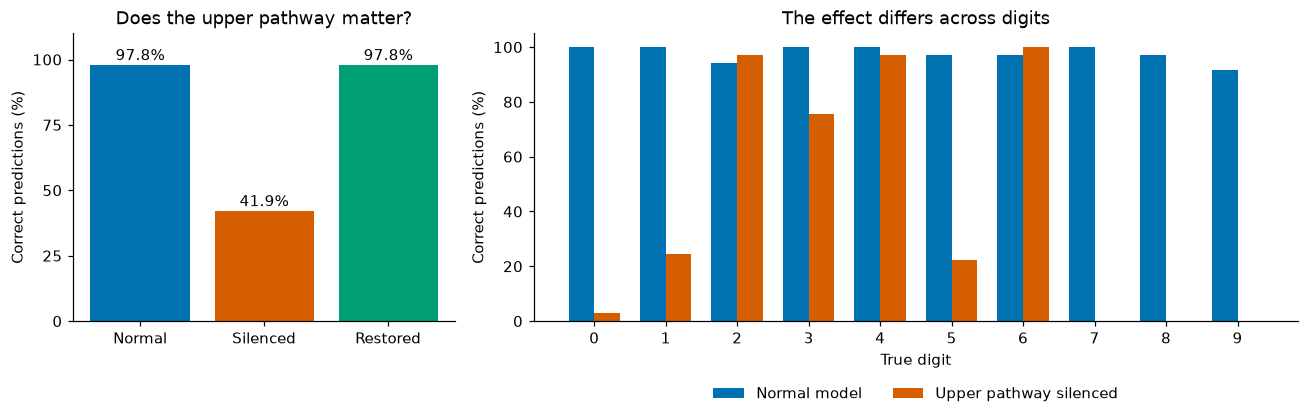

,condition,accuracy_percent
0,Normal model,97.777778
1,Upper pathway silenced,41.944444
2,After cleanup,97.777778


In [6]:
# Read saved measurements; this does not call the model again.
events = list(result.record.events())  # Keep the events for both analyses below.
responses = {event['condition']: event['payload'].payload
             for event in events if event['kind'] == 'output'}
activity = {(event['condition'], event['payload']['target']): event['payload']['value']['array']
            for event in events if event['kind'] == 'activity'}
conditions = list(responses)
for response in responses.values():
    np.testing.assert_array_equal(response['sample_ids'], test_ids)
accuracy = {condition: 100 * np.mean(response['predicted_digit'] == y_test)
            for condition, response in responses.items()}
per_digit = {condition: [100 * np.mean(response['predicted_digit'][y_test == digit] == digit)
                         for digit in range(10)]
             for condition, response in responses.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [1, 2]})
for index, condition in enumerate(conditions):
    axes[0].bar(index, accuracy[condition], color=COLORS[condition], label=LABELS[condition])
    axes[0].text(index, accuracy[condition] + 2, f'{accuracy[condition]:.1f}%', ha='center')
axes[0].set_xticks(range(3), ['Normal', 'Silenced', 'Restored'])
axes[0].set_ylabel('Correct predictions (%)')
axes[0].set_ylim(0, 110)
axes[0].set_yticks([0, 25, 50, 75, 100])
axes[0].set_title('Does the upper pathway matter?')
x = np.arange(10)
for offset, condition in [(-0.18, 'normal'), (0.18, 'silenced')]:
    axes[1].bar(x + offset, per_digit[condition], width=.36,
                color=COLORS[condition], label=LABELS[condition])
axes[1].set_xticks(x)
axes[1].set_xlabel('True digit')
axes[1].set_ylabel('Correct predictions (%)')
axes[1].set_ylim(0, 105)
axes[1].set_title('The effect differs across digits')
axes[1].legend(loc='upper center', bbox_to_anchor=(.5, -.18), ncol=2, frameon=False)
fig.tight_layout()
fig.savefig(output_root / 'accuracy.png', bbox_inches='tight')
plt.show()
pd.DataFrame({'condition': [LABELS[c] for c in conditions],
              'accuracy_percent': [accuracy[c] for c in conditions]})


## 5. Inspect recorded activity

Each cell is mean activity for one learned unit and digit. Both panels share a color scale. These are model units, not biological neurons. The checks also verify that the lower pathway and restored predictions remain unchanged.


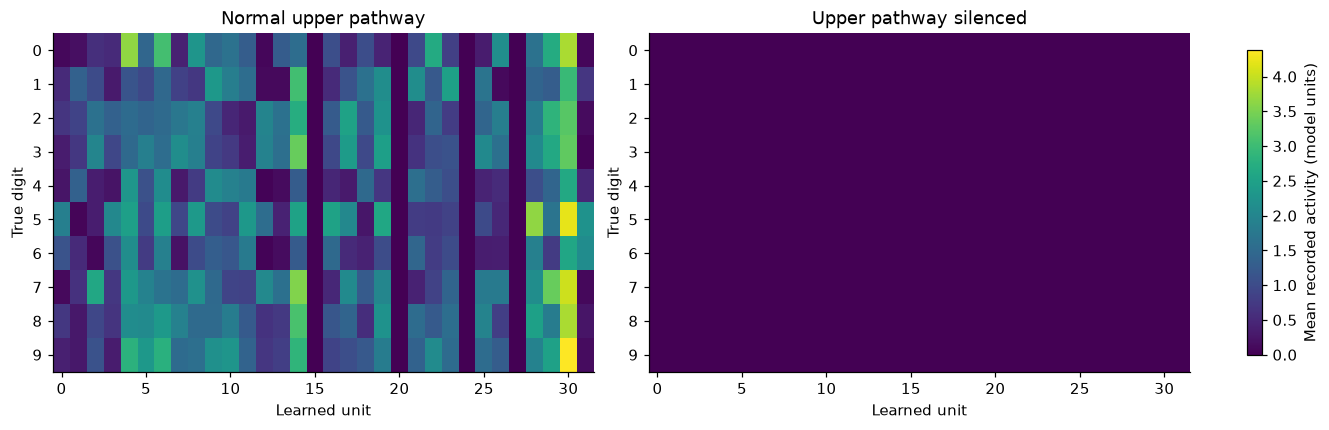

Verified: upper pathway silenced, lower activity unchanged, normal predictions restored, hooks removed.


In [7]:
normal = activity[('normal', 'upper')]
silenced = activity[('silenced', 'upper')]
means = [np.stack([values[y_test == digit].mean(axis=0) for digit in range(10)])
         for values in [normal, silenced]]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
vmax = max(float(means[0].max()), 1e-6)
for ax, values, title in zip(axes, means, ['Normal upper pathway', 'Upper pathway silenced']):
    im = ax.imshow(values, cmap='viridis', vmin=0, vmax=vmax, aspect='auto', interpolation='nearest')
    ax.set_title(title)
    ax.set_xlabel('Learned unit')
    ax.set_ylabel('True digit')
    ax.set_yticks(range(10))
fig.colorbar(im, ax=axes, label='Mean recorded activity (model units)', shrink=.9)
fig.savefig(output_root / 'activity.png', bbox_inches='tight')
plt.show()

assert np.count_nonzero(silenced) == 0
np.testing.assert_array_equal(activity[('normal', 'lower')], activity[('silenced', 'lower')])
np.testing.assert_array_equal(responses['normal']['probabilities'], responses['restored']['probabilities'])
assert not model.upper._forward_hooks and not model.lower._forward_hooks
print('Verified: upper pathway silenced, lower activity unchanged, normal predictions restored, hooks removed.')


## 6. Replay the inputs

Send the saved inputs through the model again, explicitly reattaching the same intervention. This repeats model calls; it does not regenerate feedback from an environment.


In [8]:
# Start a separate run using the saved inputs.
replayed = Experiment(
    subject=subject,  # The model adapter to run.
    protocol=replay_sessions(result.directory),  # Reuse the original inputs and condition names.
    # Record again and explicitly repeat the intervention; replay does not attach it automatically.
    tools=[RecordInputsOutputs(), Ablate(['upper'], conditions=['silenced'])],
    instrumentation=TorchInstrumentation(model),
    output_dir=output_root / 'replay',
    metadata={'checkpoint_sha256': checkpoint_hash},
).run()
# Check whether the two runs returned exactly the same outputs.
comparison = compare_outputs(result.directory, replayed.directory)
assert comparison['equal'], comparison
assert accuracy['normal'] >= 90, 'Unexpectedly poor training; inspect the environment and training loss.'
print('Exact replay:', comparison['equal'])
print('Accuracy (%):', accuracy)
print('Saved experiment:', result.directory)


Exact replay: True
Accuracy (%): {'normal': 97.77777777777777, 'silenced': 41.94444444444444, 'restored': 97.77777777777777}
Saved experiment: /var/folders/h6/g53mxg516n538136hh74630r0000gn/T/umi-digit-toolbox-cqmpm2wb/experiment


## What this shows

One setup records behavior and activity, applies an intervention, and checks restoration. This single split and seed demonstrate the workflow, not a general claim about digit recognition. Saved weights and split identify the run.

Try `lower` as the target, using a fresh output folder. See the [tool guide](../docs/experiment_toolbox.md) to add your own tool. Figures, weights, and split are written by the notebook alongside the experiment; they are not automatically registered tool artifacts.


[Notebook guide](README.md) · [Shared vocabulary](../docs/conventions.md)
